# 02. Análisis exploratorio del grafo Elliptic

Este notebook tiene como objetivo construir el grafo dirigido de transacciones Bitcoin a partir del dataset Elliptic y analizar su estructura inicial: nodos, aristas, grados, conectividad, distribución temporal y distribución de clases por timestep.

In [1]:
# Imports
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from aml_gnn.utils.paths import INTERIM_DIR, REPORTS_DIR
from aml_gnn.graph.build_networkx import build_directed_graph
from aml_gnn.graph.graph_stats import graph_basic_stats, top_degree_nodes
from aml_gnn.features.node_features import add_degree_features

print("PROJECT_ROOT:", PROJECT_ROOT)
print("INTERIM_DIR:", INTERIM_DIR)
print("REPORTS_DIR:", REPORTS_DIR)

PROJECT_ROOT: /home/lucho/aml-gnn-tesis
INTERIM_DIR: /home/lucho/aml-gnn-tesis/data/interim/elliptic
REPORTS_DIR: /home/lucho/aml-gnn-tesis/reports


In [2]:
nodes_path = INTERIM_DIR / "nodes_interim.parquet"
edges_path = INTERIM_DIR / "edges_interim.parquet"

nodes_df = pd.read_parquet(nodes_path)
edges_df = pd.read_parquet(edges_path)

print("Nodes:", nodes_df.shape)
print("Edges:", edges_df.shape)

Nodes: (203769, 168)
Edges: (234355, 2)


REVISANDO LA ESTRUCTURA DE LOS DATOS

In [3]:

nodes_df.head()

,txId,timestep,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,...,f_156,f_157,f_158,f_159,f_160,f_161,f_162,f_163,f_164,label
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,licit
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown


In [4]:
edges_df.head()

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [6]:
# Construccion del grafo dirigido
G = build_directed_graph(edges_df)

print("Número de nodos en grafo:", G.number_of_nodes())
print("Número de aristas en grafo:", G.number_of_edges())
print("Confirmacion si es dirigido o no:", G.is_directed())

Número de nodos en grafo: 203769
Número de aristas en grafo: 234355
Confirmacion si es dirigido o no: True


In [8]:
# Estadisticas basicas del grafo
stats = graph_basic_stats(G)
stats

{'num_nodes': 203769,
 'num_edges': 234355,
 'density': 5.644170528459417e-06,
 'is_directed': True,
 'avg_in_degree': 1.1501013402431184,
 'avg_out_degree': 1.1501013402431184,
 'avg_total_degree': 2.3002026804862368,
 'max_in_degree': 284,
 'max_out_degree': 472,
 'max_total_degree': 473,
 'num_weakly_connected_components': 49,
 'num_strongly_connected_components': 203769}

In [12]:
# Pasando las estadisticas a tabla
graph_stats_df = pd.DataFrame(
    list(stats.items()),
    columns=["metric", "value"]
)

print(graph_stats_df)

# Guardando las estadisticas del grafo
tables_dir = REPORTS_DIR / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

graph_stats_path = tables_dir / "graph_basic_stats.csv"
graph_stats_df.to_csv(graph_stats_path, index=False)

                               metric     value
0                           num_nodes    203769
1                           num_edges    234355
2                             density  0.000006
3                         is_directed      True
4                       avg_in_degree  1.150101
5                      avg_out_degree  1.150101
6                    avg_total_degree  2.300203
7                       max_in_degree       284
8                      max_out_degree       472
9                    max_total_degree       473
10    num_weakly_connected_components        49
11  num_strongly_connected_components    203769


In [13]:
# Agregando grados a los nodos
nodes_graph_df = add_degree_features(nodes_df, G)

nodes_graph_df[["txId", "label", "timestep", "in_degree", "out_degree", "total_degree"]].head()

,txId,label,timestep,in_degree,out_degree,total_degree
0,230425980,unknown,1,1,1,2
1,5530458,unknown,1,1,1,2
2,232022460,unknown,1,1,2,3
3,232438397,licit,1,160,1,161
4,230460314,unknown,1,2,8,10


In [14]:
# Resumen de grados
degree_summary = nodes_graph_df[["in_degree", "out_degree", "total_degree"]].describe().T
degree_summary

,count,mean,std,min,25%,50%,75%,max
in_degree,203769.0,1.150101,3.911132,0.0,0.0,1.0,1.0,284.0
out_degree,203769.0,1.150101,1.894740,0.0,1.0,1.0,1.0,472.0
total_degree,203769.0,2.300203,4.328377,1.0,1.0,2.0,2.0,473.0


In [15]:
# Guardando tabla de nodos con grados
nodes_graph_path = INTERIM_DIR / "nodes_with_graph_features.parquet"
nodes_graph_df.to_parquet(nodes_graph_path, index=False)

print("Guardado:", nodes_graph_path)

Guardado: /home/lucho/aml-gnn-tesis/data/interim/elliptic/nodes_with_graph_features.parquet


In [16]:
# Distribucion de clases
class_distribution = (
    nodes_graph_df["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)

class_distribution["percentage"] = (
    class_distribution["count"] / class_distribution["count"].sum() * 100
).round(2)

class_distribution

,label,count,percentage
0,unknown,157205,77.15
1,licit,42019,20.62
2,illicit,4545,2.23


In [17]:
# Guardando distribucion de clases
class_distribution_path = tables_dir / "class_distribution.csv"
class_distribution.to_csv(class_distribution_path, index=False)

print("Guardado:", class_distribution_path)

Guardado: /home/lucho/aml-gnn-tesis/reports/tables/class_distribution.csv


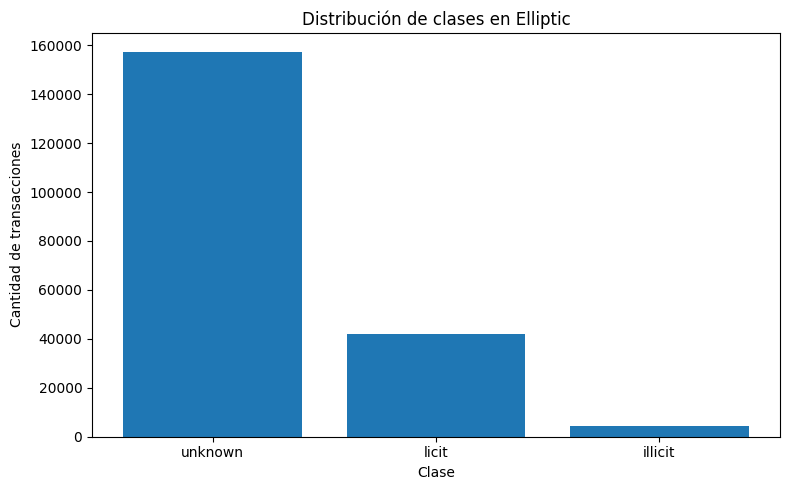

Guardado: /home/lucho/aml-gnn-tesis/reports/figures/class_distribution.png


In [18]:
# Grafico de distribucion de clases
figures_dir = REPORTS_DIR / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.bar(class_distribution["label"], class_distribution["count"])
plt.title("Distribución de clases en Elliptic")
plt.xlabel("Clase")
plt.ylabel("Cantidad de transacciones")
plt.xticks(rotation=0)
plt.tight_layout()

class_fig_path = figures_dir / "class_distribution.png"
plt.savefig(class_fig_path, dpi=300)
plt.show()

print("Guardado:", class_fig_path)

In [19]:
# Distribucion de transacciones por timestep
timestep_distribution = (
    nodes_graph_df
    .groupby("timestep")
    .size()
    .reset_index(name="num_transactions")
)

timestep_distribution.head()

,timestep,num_transactions
0,1,7880
1,2,4544
2,3,6621
3,4,5693
4,5,6803


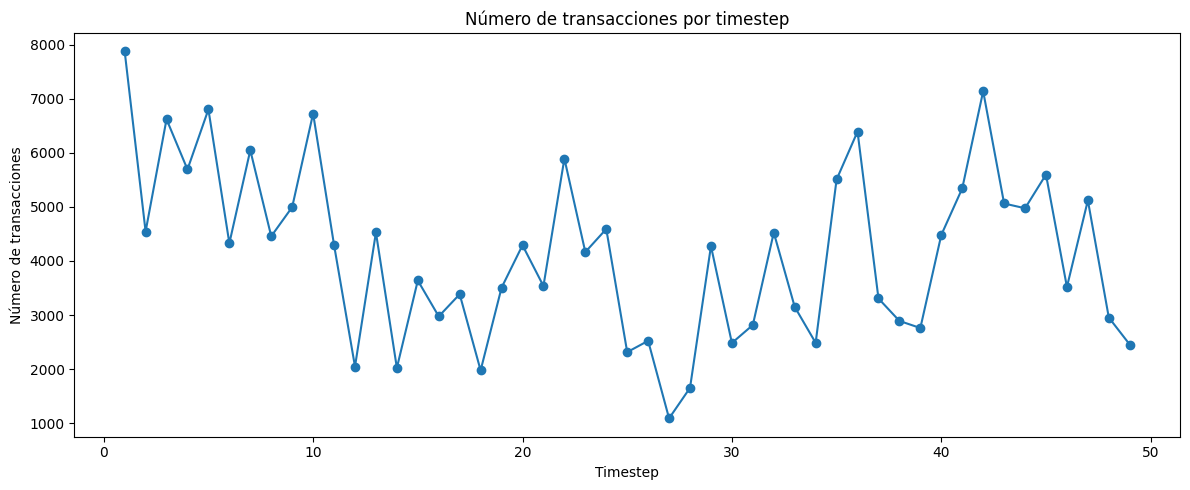

Guardado: /home/lucho/aml-gnn-tesis/reports/figures/transactions_by_timestep.png


In [20]:
# Grafico de transacciones por timestep
plt.figure(figsize=(12, 5))
plt.plot(
    timestep_distribution["timestep"],
    timestep_distribution["num_transactions"],
    marker="o"
)
plt.title("Número de transacciones por timestep")
plt.xlabel("Timestep")
plt.ylabel("Número de transacciones")
plt.tight_layout()

timestep_fig_path = figures_dir / "transactions_by_timestep.png"
plt.savefig(timestep_fig_path, dpi=300)
plt.show()

print("Guardado:", timestep_fig_path)

In [21]:
# Clases por timestep
classes_by_timestep = (
    nodes_graph_df
    .groupby(["timestep", "label"])
    .size()
    .reset_index(name="count")
)

classes_by_timestep.head()

,timestep,label,count
0,1,illicit,17
1,1,licit,2130
2,1,unknown,5733
3,2,illicit,18
4,2,licit,1099


In [22]:
# Tabla pivote de clases por timestep
classes_by_timestep_pivot = classes_by_timestep.pivot(
    index="timestep",
    columns="label",
    values="count"
).fillna(0).astype(int)

classes_by_timestep_pivot.head()

label,illicit,licit,unknown
timestep,,,
1,17,2130,5733
2,18,1099,3427
3,11,1268,5342
4,30,1410,4253
5,8,1874,4921


In [23]:
# Guardar clases por timestep
classes_by_timestep_path = tables_dir / "classes_by_timestep.csv"
classes_by_timestep_pivot.to_csv(classes_by_timestep_path)

print("Guardado:", classes_by_timestep_path)

Guardado: /home/lucho/aml-gnn-tesis/reports/tables/classes_by_timestep.csv


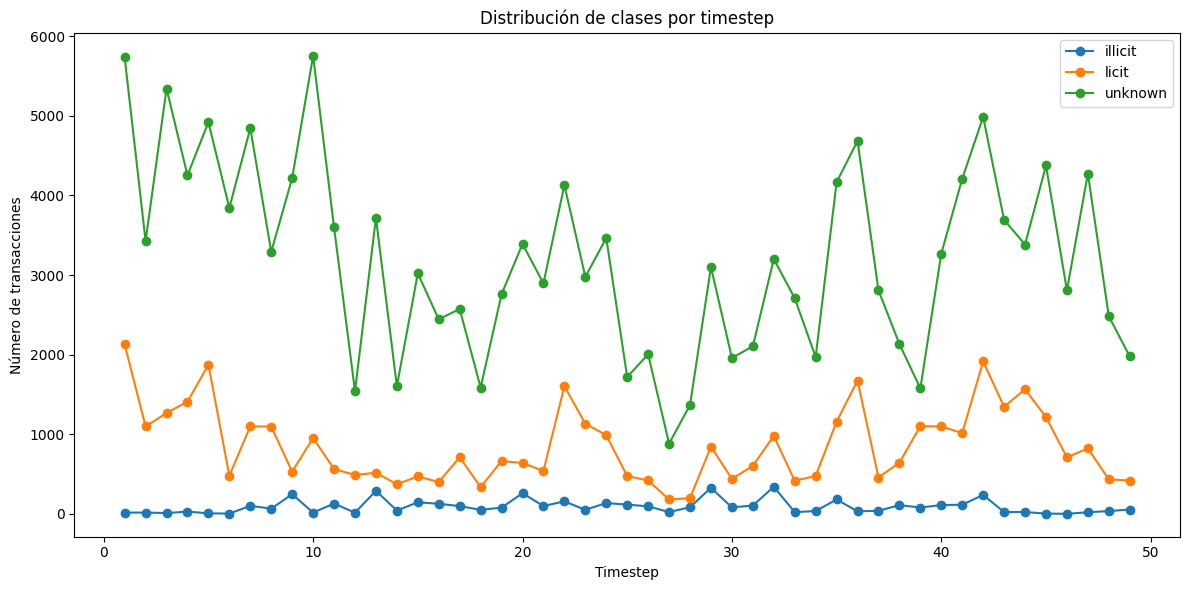

Guardado: /home/lucho/aml-gnn-tesis/reports/figures/classes_by_timestep.png


In [24]:
# Grafico de clases por timestep
plt.figure(figsize=(12, 6))

for label in classes_by_timestep_pivot.columns:
    plt.plot(
        classes_by_timestep_pivot.index,
        classes_by_timestep_pivot[label],
        marker="o",
        label=label
    )

plt.title("Distribución de clases por timestep")
plt.xlabel("Timestep")
plt.ylabel("Número de transacciones")
plt.legend()
plt.tight_layout()

classes_timestep_fig_path = figures_dir / "classes_by_timestep.png"
plt.savefig(classes_timestep_fig_path, dpi=300)
plt.show()

print("Guardado:", classes_timestep_fig_path)

In [25]:
# TOp de nodos por grado total
top_total = top_degree_nodes(G, degree_type="total", top_n=10)
top_total_df = pd.DataFrame(top_total, columns=["txId", "total_degree"])

top_total_df = top_total_df.merge(
    nodes_graph_df[["txId", "label", "timestep", "in_degree", "out_degree"]],
    on="txId",
    how="left"
)

top_total_df

,txId,total_degree,label,timestep,in_degree,out_degree
0,2984918,473,licit,22,1,472
1,89273,289,licit,1,1,288
2,43388675,284,licit,10,284,0
3,68705820,247,licit,10,247,0
4,30699343,241,licit,37,241,0
5,96576418,239,licit,7,239,0
6,225859042,212,unknown,5,212,0
7,279187194,211,licit,4,211,0
8,234890810,199,unknown,11,199,0
9,196107869,188,licit,46,188,0


In [29]:
# Top de nodos por grado de entrada
top_in = top_degree_nodes(G, degree_type="in", top_n=10)
top_in_df = pd.DataFrame(top_in, columns=["txId", "in_degree"])

top_in_df = top_in_df.merge(
    nodes_graph_df[["txId", "label", "timestep", "out_degree", "total_degree"]],
    on="txId",
    how="left"
)

top_in_df

,txId,in_degree,label,timestep,out_degree,total_degree
0,43388675,284,licit,10,0,284
1,68705820,247,licit,10,0,247
2,30699343,241,licit,37,0,241
3,96576418,239,licit,7,0,239
4,225859042,212,unknown,5,0,212
5,279187194,211,licit,4,0,211
6,234890810,199,unknown,11,0,199
7,196107869,188,licit,46,0,188
8,43397277,182,licit,10,0,182
9,68706499,178,licit,10,0,178


In [27]:
# Top de nodos por grado de salida
top_out = top_degree_nodes(G, degree_type="out", top_n=10)
top_out_df = pd.DataFrame(top_out, columns=["txId", "out_degree"])

top_out_df = top_out_df.merge(
    nodes_graph_df[["txId", "label", "timestep", "in_degree", "total_degree"]],
    on="txId",
    how="left"
)

top_out_df

,txId,out_degree,label,timestep,in_degree,total_degree
0,2984918,472,licit,22,1,473
1,89273,288,licit,1,1,289
2,102570,122,unknown,36,0,122
3,3181,112,licit,34,1,113
4,7952,99,licit,48,1,100
5,1891081,95,unknown,27,0,95
6,143705,92,unknown,45,0,92
7,565334,90,licit,10,1,91
8,488266,88,licit,25,1,89
9,793584,82,unknown,43,1,83


In [30]:
# Guardando top nodos 
top_total_df.to_csv(tables_dir / "top_total_degree_nodes.csv", index=False)
top_in_df.to_csv(tables_dir / "top_in_degree_nodes.csv", index=False)
top_out_df.to_csv(tables_dir / "top_out_degree_nodes.csv", index=False)

print("Tablas de top nodos guardadas.")

Tablas de top nodos guardadas.


In [31]:
# Resumen temporal y de etiquetado

temporal_summary = {
    "min_timestep": int(nodes_graph_df["timestep"].min()),
    "max_timestep": int(nodes_graph_df["timestep"].max()),
    "num_timesteps": int(nodes_graph_df["timestep"].nunique()),
    "num_total_nodes": int(nodes_graph_df.shape[0]),
    "num_labeled_nodes": int(nodes_graph_df["label"].isin(["licit", "illicit"]).sum()),
    "num_unknown_nodes": int((nodes_graph_df["label"] == "unknown").sum()),
    "num_licit_nodes": int((nodes_graph_df["label"] == "licit").sum()),
    "num_illicit_nodes": int((nodes_graph_df["label"] == "illicit").sum()),
}

temporal_summary

{'min_timestep': 1,
 'max_timestep': 49,
 'num_timesteps': 49,
 'num_total_nodes': 203769,
 'num_labeled_nodes': 46564,
 'num_unknown_nodes': 157205,
 'num_licit_nodes': 42019,
 'num_illicit_nodes': 4545}

In [32]:
# Distribución considerando solo nodos etiquetados: licit vs illicit

labeled_nodes_df = nodes_graph_df[
    nodes_graph_df["label"].isin(["licit", "illicit"])
].copy()

labeled_class_distribution = (
    labeled_nodes_df["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)

labeled_class_distribution["percentage"] = (
    labeled_class_distribution["count"] /
    labeled_class_distribution["count"].sum() * 100
).round(2)

labeled_class_distribution

,label,count,percentage
0,licit,42019,90.24
1,illicit,4545,9.76


In [33]:
import json

metrics_dir = REPORTS_DIR / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

level_1_summary = {
    "graph_stats": stats,
    "temporal_summary": temporal_summary,
    "class_distribution": class_distribution.to_dict(orient="records"),
    "labeled_class_distribution": labeled_class_distribution.to_dict(orient="records"),
}

level_1_summary_path = metrics_dir / "level_1_eda_summary.json"

with open(level_1_summary_path, "w", encoding="utf-8") as file:
    json.dump(level_1_summary, file, indent=4, ensure_ascii=False)

print("Guardado:", level_1_summary_path)

Guardado: /home/lucho/aml-gnn-tesis/reports/metrics/level_1_eda_summary.json
